### Evaluation of NHF Routing

#### Author: Tadd Bindas

This code assumed the following outputs have been created from a t-route run using the command:
`uv run python -m nwm_routing -V5 -f test_case.yaml` 
from the `test/mhf/conecuh_case` directory


In [ ]:
from pathlib import Path

import folium
import geopandas as gpd
import numpy as np
import pandas as pd
import xarray as xr
from folium import GeoJson, LayerControl


Before looking at the routing output, let's examine the domain/NHF geopackage

In [ ]:
gpkg_path = "domain/02374250.gpkg"

# List available layers
layers = gpd.list_layers(gpkg_path)
print(layers)

# Create map centered on data
first_layer = gpd.read_file(gpkg_path, layer=layers.iloc[0]["name"])
bounds = first_layer.total_bounds
center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

m = folium.Map(location=center, zoom_start=10)

# Style configs per layer
styles = {
    "flowpaths": {"color": "blue", "weight": 2},
    "divides": {"color": "green", "weight": 1, "fillOpacity": 0.3},
    "nexus": {"color": "red", "weight": 3},
}

# Add each layer
for _, row in layers.iterrows():
    layer_name = row["name"]
    gdf = gpd.read_file(gpkg_path, layer=layer_name).to_crs(epsg=4326)
    
    style = styles.get(layer_name, {"color": "gray", "weight": 1})
    
    GeoJson(
        gdf,
        name=layer_name,
        style_function=lambda x, s=style: s,
        tooltip=folium.GeoJsonTooltip(fields=list(gdf.columns[:3]))
    ).add_to(m)

LayerControl().add_to(m)
m.save("output/hydrofabric_layers.html")
m


In [ ]:
ds_ = xr.open_dataset(Path.cwd() / "output/troute_output_200001010000.nc", engine="netcdf4")
ds_2 = xr.open_dataset(Path.cwd() / "output/troute_output_200001130000.nc", engine="netcdf4")
ds = xr.concat([ds_, ds_2], dim="time")

output_dir = Path("channel_forcing")
streamflow = []
for file in sorted(list(output_dir.glob("*.csv"))):
    _df = pd.read_csv(file)
    streamflow.append(np.sum(_df["streamflow"].values).item())


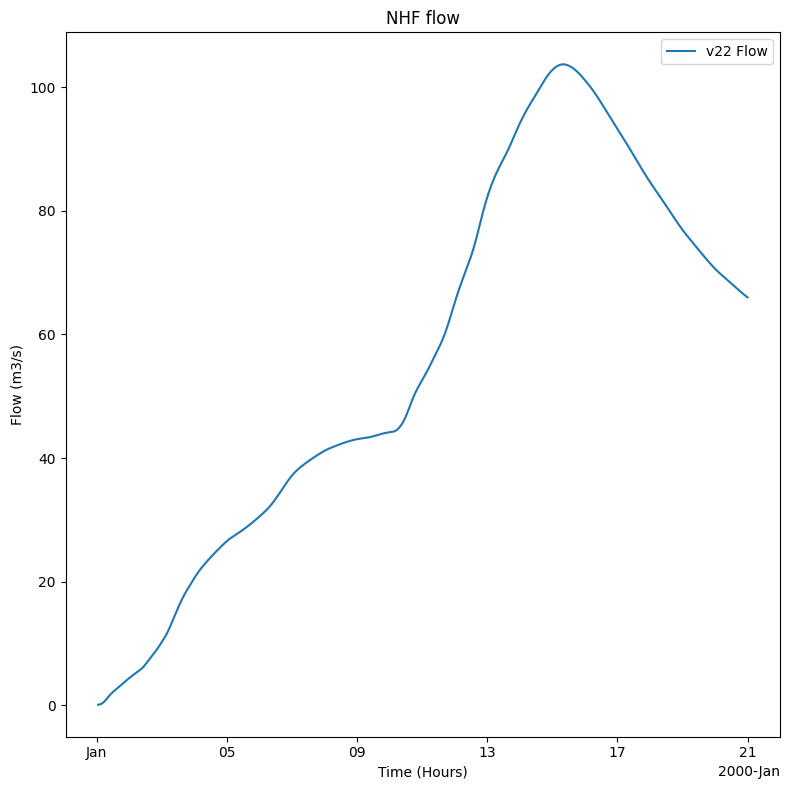

In [ ]:
import matplotlib.pyplot as plt

dates = pd.date_range(start="2000-01-01", periods=len(streamflow), freq="h")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, streamflow, label="Simulated", color="orange")
ax.set_xlabel("Date")
ax.set_ylabel("Streamflow")
ax.legend()
plt.tight_layout()
plt.show()

_id = 3493573

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ds.sel(feature_id=_id).flow.plot(ax=ax, label='v22 Flow')
ax.set_title('NHF flow')
ax.set_xlabel('Time (Hours)')
ax.set_ylabel('Flow (m3/s)')
ax.legend()

plt.tight_layout()

plt.show()


Given the forcings from the IDS are no mapped 1 to 1 perfectly, and the flowlines / nexus connectivity graphs are different, and Manning's roughness values, seeing a similar rise from the forcings and parallel slope timing indicates v2.2 is working successfully